In [3]:
import os
os.path.exists('/content/drive/MyDrive')

False

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_parquet("/content/drive/MyDrive/amazon_reviews_clean.parquet")
print(df.shape)
df['sentiment'].value_counts()

(74545, 9)


,count
sentiment,
positive,58302
negative,9581
neutral,6662


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train size: (59636,)
Test size: (14909,)
sentiment
positive    0.782111
negative    0.128530
neutral     0.089359
Name: proportion, dtype: float64
sentiment
positive    0.782078
negative    0.128513
neutral     0.089409
Name: proportion, dtype: float64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english',
    lowercase=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)

Train TF-IDF shape: (59636, 20000)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_tfidf, y_train)
print("Training complete")

Training complete


              precision    recall  f1-score   support

    negative       0.55      0.70      0.61      1916
     neutral       0.26      0.48      0.34      1333
    positive       0.95      0.81      0.88     11660

    accuracy                           0.77     14909
   macro avg       0.59      0.66      0.61     14909
weighted avg       0.84      0.77      0.80     14909

Macro F1: 0.6095044472891874


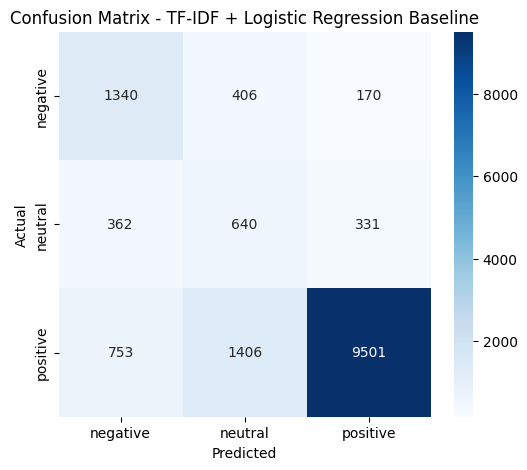

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF + Logistic Regression Baseline')
plt.show()

In [10]:
import json

baseline_results = {
    "model": "TF-IDF + Logistic Regression",
    "macro_f1": 0.6095,
    "accuracy": 0.77,
    "negative_f1": 0.61,
    "neutral_f1": 0.34,
    "positive_f1": 0.88
}

with open("baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved baseline results")

Saved baseline results


In [11]:
import shutil
shutil.copy("baseline_results.json", "/content/drive/MyDrive/baseline_results.json")

'/content/drive/MyDrive/baseline_results.json'